In [32]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Russian_Demography_1990_2017.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2380 entries, 0 to 2379
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          2380 non-null   int64  
 1   region        2380 non-null   str    
 2   npg           2317 non-null   float64
 3   birth_rate    2317 non-null   float64
 4   death_rate    2315 non-null   float64
 5   gdw           2330 non-null   float64
 6   urbanization  2330 non-null   float64
dtypes: float64(5), int64(1), str(1)
memory usage: 130.3 KB


Birth rate -- the number of live births per 1,000 people in a population in a given year.

Death rate -- the number of deaths per 1,000 people in a population in a given year.

NPG (Natural Population Growth) -- the difference between the birth rate and the death rate in a population.

```NPG = birth rate − death rate```

GDW (General Demographic Weight) -- the ratio of the population of non-working age to the population of working age, expressed per 100 people of working age.

```GDW = (Population of non-working age / Population of working age) × 100```

# Task 1

Test the hypothesis that the mean birth rates in Russia were equal in 2015, 2016, and 2017. The data are assumed to be normally distributed.

In [26]:
years = [2015, 2016, 2017]

birth_rate = {}

for year in years:
    birth_rate[year] = df.loc[df["year"] == year, "birth_rate"]
    print(f"Year {year}: \
        \n\t count: {birth_rate[year].count()}\
        \n\t count nans: {birth_rate[year].isna().sum()}\
    ")

Year 2015:         
	 count: 85        
	 count nans: 0    
Year 2016:         
	 count: 85        
	 count nans: 0    
Year 2017:         
	 count: 85        
	 count nans: 0    


To perform a one-way analysis of variance (one-way ANOVA), we need to check whether the variances are equal across all three populations. We use Bartlett's test to test the equality of several variances.

We can see that the sample sizes are equal. Although equal sample sizes are not required for Bartlett's test, they are advantageous for the precision and robustness of the ANOVA.

In [45]:
bartlett_result = stats.bartlett(*birth_rate.values())
print(bartlett_result)

BartlettResult(statistic=np.float64(0.6594033534095636), pvalue=np.float64(0.7191382371232273))


The Bartlett test statistic is 0.659, with a p-value of 0.719. Since the p-value is greater than the significance level of 0.05, we fail to reject the null hypothesis that the population variances are equal. Therefore, there is no statistically significant evidence of a difference in the variances.

Since normality is an assumption of one-way ANOVA, we inspected Q-Q plots for each year. The points lie approximately along the reference line, suggesting that the distributions do not substantially deviate from normality.

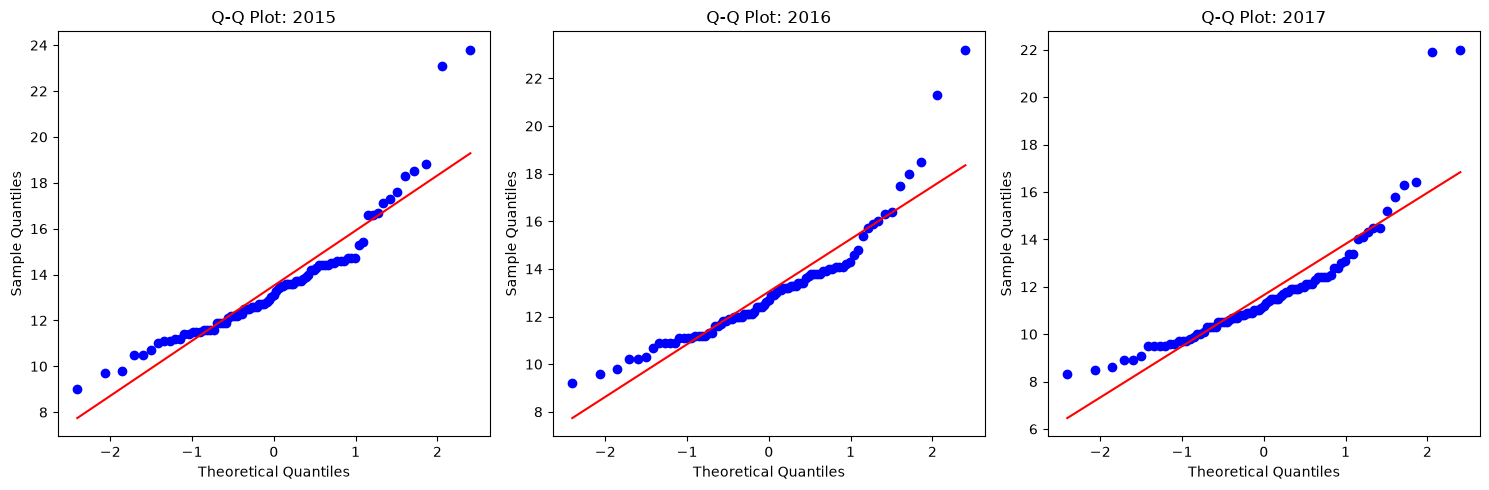

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, year in zip(axes, years):
    stats.probplot(birth_rate[year], dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot: {year}")
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")

plt.tight_layout()
plt.show()

In [46]:
anova_result = stats.f_oneway(*birth_rate.values())
print(anova_result)

F_onewayResult(statistic=np.float64(13.83228246166574), pvalue=np.float64(1.9959534521522416e-06))


The ANOVA test gives an F-statistic of 13.83 and a p-value of approximately 0.000002. Since the p-value is much smaller than 0.05, we reject the null hypothesis that the three population means are equal. This provides evidence that at least one pair of population means differs significantly.

Since the ANOVA result is statistically significant, we perform Tukey's HSD test for multiple pairwise comparisons to determine which years have significantly different mean birth rates.

In [47]:
tukey_result = stats.tukey_hsd(*birth_rate.values(), equal_var=True)
print(tukey_result)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      0.472     0.409    -0.399     1.342
 (0 - 2)      1.867     0.000     0.997     2.737
 (1 - 0)     -0.472     0.409    -1.342     0.399
 (1 - 2)      1.395     0.001     0.525     2.266
 (2 - 0)     -1.867     0.000    -2.737    -0.997
 (2 - 1)     -1.395     0.001    -2.266    -0.525



According to Tukey's HSD test, there is no statistically significant difference between the population means for 2015 and 2016 (p = 0.409). However, the differences between 2015 and 2017 (p < 0.001) and between 2016 and 2017 (p = 0.001) are statistically significant. Therefore, we fail to reject the equality of the 2015 and 2016 means, while we reject the equality of the means for both 2015 vs. 2017 and 2016 vs. 2017.